# Tennessee Eastman Process — Modellbildung

Lädt `data_campaign`/`data_production`/`data_error` aus *tep_generation*, wählt aus dem
Kampagnenpool eine Teilmenge von `N_CAMPAIGN` Betriebspunkten als Versuchskampagne,
trainiert darauf ein MLP mit fest vorgegebenem Merkmalssatz und validiert es auf den
Anfahrrampen derselben Punkte. Bewertet wird der Prädiktionsfehler auf den
Produktions- und Fehlerfalldaten, getrennt nach gesehenen und ungesehenen
Betriebspunkten und über deren Abstand zur Kampagne. Die gescorten Artefakte
`data_scored_production`/`data_scored_error` gehen an *tep_detection* und
*tep_adaptation*.

Die Screening-Zelle am Ende variiert Kampagnengröße und Validierungsschema; sie ist
Methodenarbeit und für den Hauptpfad nicht nötig.


In [1]:
FORCE_RECOMPUTE = True
IS_FINAL = True

In [2]:
# --- Konstanten ---
SEED = 42
RUN_ID = "6fe76fde"   # None -> neuester Produktionslauf
ERROR_VARIANT = {"idv": 29, "amp": 0.3}   # None -> neuester Fehlerfall
WINDOW_SIZE = 10
ARCH = [12, 12, 1]
ACT = "tanh"
EPOCHS = 200
BATCH = 200
PATIENCE = 20
VAL_SPLIT = 0.15

VAL_MODE = "ramp"       # "ramp" -> Anfahrrampen | "segment" -> ganze Betriebspunkte

SENSOR_FEATURE = "Stripper Temp"   # Wirkort der Kalibrierdrift IDV(29)
N_CAMPAIGN = 30                    # Betriebspunkte der Versuchskampagne
FEATURE_SET = ["Stripper Temp", "Purge valve", "Component E to Reactor",
               "Product Sep Temp", "MolePctGSP"]

SAMPLES_PER_H = 20
PLOT_FRAC = 0.1              # Anteil geplotteter Punkte
PLOT_YLIM = (-1e2, 1e2)      # symlog-Bereich der Fehlerachse
PLOT_EPOCH = "1970-01-01"    # Zeitstempel-Ursprung wie im synthetischen Fall

In [3]:
import tensorflow as tf   # muss zuerst geladen werden, sonst statische TLS-Slots erschöpft (DLL-Fehler 1114)
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [4]:
import numpy as np

rng = np.random.default_rng(SEED)

## Daten laden

In [5]:
from src.utils import run_registry as rr
ledger = rr.run_ledger(work_dir)
data_store = rr.tep_data_store(data_dir)
model_store = rr.tep_model_store(model_dir)
plot_store = rr.tep_plot_store(plot_dir, ledger=ledger)
res_store = rr.tep_results_store(results_dir, ledger=ledger)

# base_cfg traegt data_campaign, production_cfg zusaetzlich data_production und data_error.
# rename=False bei allen drei Generierungs-Artefakten: sie stammen aus venv_37
# (pandas 1.3.5) und duerfen hier nicht neu geschrieben werden -- venv_37 koennte
# sie danach nicht mehr lesen. Die Schreibrichtung ist einbahnig: 37 schreibt, 311 liest.
prod_id = data_store.latest_id("data_production") if RUN_ID is None else RUN_ID
if prod_id is None:
    raise FileNotFoundError("Kein production-Artefakt. Bitte tep_generation.ipynb ausfuehren.")
production_data = data_store.load("data_production", run_id=prod_id, rename=False)
production_cfg = rr.RunConfig.from_document(production_data.attrs.get("config", production_data.attrs))

try:
    campaign_data = data_store.load("data_campaign", run_id=production_cfg.base_id, rename=False)
except FileNotFoundError:
    import glob as _g, os as _o, json as _j
    _av = []
    for _p in _g.glob(_o.path.join(str(data_dir), f"{data_store.prefix}_data_campaign_*.json")):
        with open(_p, encoding="utf-8") as _f:
            _av.append(_j.load(_f).get("id"))
    raise FileNotFoundError(
        f"Kampagnenartefakt zu base_id={production_cfg.base_id} fehlt. Vorhanden: {_av}. "
        "Der Produktionslauf gehoert dann zu einem anderen Versuchsplan -- "
        "tep_generation mit demselben Stand durchlaufen lassen.")
base_cfg = rr.RunConfig.from_document(campaign_data.attrs.get("config", campaign_data.attrs))

run_cfg = dict(base_cfg.document)
ramp_duration = run_cfg["ramp_h"]
soak_time = run_cfg["soak_h"]

error_data, error_cfg = rr.load_section(data_store, "data_error", production_cfg, "error",
                                        ERROR_VARIANT, rename=False)
error_variant = error_cfg.sections["error"]
ERROR_VARIANT_ID = error_variant["idv"]
if "driftf" not in error_data.columns:
    raise ValueError("data_error hat keine Spalte 'driftf'. Bitte die Zelle "
                     "'Gemessenes driftf als Spalte' in tep_generation ausfuehren.")

ledger.bind("model", parents={"production": production_cfg.id, "error": error_cfg.id})

print(f"base_id = {base_cfg.id} | run_id = {production_cfg.id} | error_run_id = {error_cfg.id} "
      f"(IDV {ERROR_VARIANT_ID}, amp {error_variant['amp']})")
print(f"Kampagnenpool {campaign_data['mode'].nunique()} Punkte, "
      f"Produktion {production_data['mode'].nunique()} Punkte, "
      f"Fehlerfall {error_data['mode'].nunique()} Punkte")

base_id = 30098669 | run_id = 6fe76fde | error_run_id = a568acfa (IDV 29, amp 0.3)
Kampagnenpool 137 Punkte, Produktion 121 Punkte, Fehlerfall 121 Punkte


## Vorverarbeitung

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


def preprocess(df: pd.DataFrame, scaler, fit: bool = False) -> pd.DataFrame:
    """Skalierung und Glaettung; Metadatenspalten bleiben unskaliert."""
    unchanged = [c for c in df.columns
                 if c in ["mode", "original_index", "reset", "status", "time",
                          "driftf", "drift_segment"]
                 or c.startswith("IDV")]
    numeric = df.drop(columns=unchanged)
    array = scaler.fit_transform(numeric) if fit else scaler.transform(numeric)
    scaled = pd.DataFrame(array, columns=numeric.columns, index=numeric.index)
    smoothed = scaled.rolling(window=WINDOW_SIZE, min_periods=1).mean()
    smoothed[unchanged] = df[unchanged]
    return smoothed

Skalierung und Glättung

In [7]:
scaler = MinMaxScaler()
campaign_smoothed_data = preprocess(campaign_data, scaler, fit=True)

Stationäre Bereiche wählen

In [8]:
def static_steady_mask(df: pd.DataFrame, ramp_duration: float, soak_time: float):
    mask = pd.Series(False, index=df.index)
    for mode in df["mode"].unique():
        mode_data = df[df["mode"] == mode]
        start_time = mode_data["time"].min() + ramp_duration
        end_time = start_time + soak_time - ramp_duration
        mask.loc[mode_data[(mode_data["time"] >= start_time) & (mode_data["time"] <= end_time)].index] = True

    return mask


def static_ramp_mask(df: pd.DataFrame, ramp_duration: float, skip: int = None):
    """Anfahrrampe je Block, ohne die ersten `skip` Zeilen der Blockgrenze."""
    skip = WINDOW_SIZE if skip is None else skip
    mask = pd.Series(False, index=df.index)
    for mode in df["mode"].unique():
        mode_data = df[df["mode"] == mode]
        t0 = mode_data["time"].min()
        sel = mode_data[(mode_data["time"] >= t0)
                        & (mode_data["time"] < t0 + ramp_duration)].index[skip:]
        mask.loc[sel] = True
    return mask

In [9]:
campaign_stationary_mask = static_steady_mask(campaign_smoothed_data,
                                              ramp_duration, soak_time)

In [10]:
def find_stationary_ranges(df_smoothed, stationary_mask, same_length:bool=True):
    stationary_changes = stationary_mask.astype(int).diff().fillna(0)
    starts = df_smoothed.index[stationary_changes == 1]
    ends = df_smoothed.index[stationary_changes == -1]

    # Edge cases
    if df_smoothed.index[stationary_mask][0] == df_smoothed.index[0]:
        starts = starts.insert(0, df_smoothed.index[0])
    if df_smoothed.index[stationary_mask][-1] == df_smoothed.index[-1]:
        ends = ends.append(pd.Index([df_smoothed.index[-1]]))

    stationary_ranges = list(zip(starts, ends))
    if not same_length:
        return stationary_ranges
    else:
        min_duration = min([end - start for start, end in stationary_ranges])
        stationary_ranges = [(start, start + min_duration) for start, end in stationary_ranges]
        return stationary_ranges

In [11]:
campaign_stationary_ranges = find_stationary_ranges(campaign_smoothed_data, campaign_stationary_mask, same_length=False)

In [12]:
campaign_means_all = pd.concat([campaign_smoothed_data.loc[(campaign_smoothed_data["original_index"]>=start) & 
                                      (campaign_smoothed_data["original_index"]<=end),:].mean(axis=0, numeric_only=True) 
                                      for start, end in campaign_stationary_ranges], axis=1).T

### Kampagne: Teilmenge der gefahrenen Punkte

`campaign_data` enthält alle fahrbaren Betriebspunkte. Trainiert wird nur auf einer Teilmenge — sonst hat das Modell jeden Produktionspunkt schon gesehen, jeder Abstand ist null und die Unterscheidung Kampagne/Produktion ist leer.

Die sechs Modusnennwerte sind gesetzt, der Rest wird per Maximin im skalierten Sollwertraum aufgefüllt: dokumentierte Rezepte plus möglichst weit gestreute Variationen. Auch Merkmalsauswahl und Korrelationen laufen ab hier nur noch auf der Kampagne — sonst flösse Wissen über die Produktionspunkte in das Modell ein.


In [13]:
from scipy.spatial.distance import cdist

campaign_means_all["mode"] = campaign_means_all["mode"].round().astype(int)
_range_modes = campaign_means_all["mode"].to_numpy()       # Reihenfolge = ranges
campaign_means_all = campaign_means_all.set_index("mode", drop=False)

setpoint_cols = [c for c in campaign_means_all.columns if c.endswith("SP")]
campaign_sp_scaled = campaign_means_all[setpoint_cols]
campaign_sp_scaled = ((campaign_sp_scaled - campaign_sp_scaled.min())
                      / (campaign_sp_scaled.max() - campaign_sp_scaled.min()).replace(0.0, 1.0))

def pick_campaign(n):
    """Modusnennwerte plus Maximin-Auffuellung im skalierten Sollwertraum."""
    sel = [int(m) for m in campaign_sp_scaled.index if m < 6]
    while len(sel) < n and len(sel) < len(campaign_sp_scaled):
        d = cdist(campaign_sp_scaled.to_numpy(),
                  campaign_sp_scaled.loc[sel].to_numpy()).min(axis=1)
        d[[campaign_sp_scaled.index.get_loc(m) for m in sel]] = -1.0
        sel.append(int(campaign_sp_scaled.index[int(np.argmax(d))]))
    return sel


def campaign_subset(modes):
    """(stationary_means, ranges) fuer eine Kampagnenauswahl."""
    return (campaign_means_all.loc[modes],
            [r for r, m in zip(campaign_stationary_ranges, _range_modes)
             if m in set(modes)])


campaign_modes = pick_campaign(N_CAMPAIGN)
stationary_means, campaign_ranges = campaign_subset(campaign_modes)

print(f"Kampagnenpool {len(campaign_means_all)} Punkte -> Kampagne {len(campaign_modes)}: "
      f"{sorted(campaign_modes)}")
print(f"  davon Modusnennwerte: {sorted(m for m in campaign_modes if m < 6)}")
_dm = cdist(campaign_sp_scaled.to_numpy(), campaign_sp_scaled.loc[campaign_modes].to_numpy()).min(axis=1)
print(f"  Abstand der uebrigen Poolpunkte zur Kampagne: Median {np.median(_dm):.3f}, "
      f"max {_dm.max():.3f} (skalierter Sollwertraum, 12 Dimensionen)")

Kampagnenpool 137 Punkte -> Kampagne 30: [0, 1, 2, 3, 4, 5, 11, 24, 29, 42, 56, 64, 69, 84, 87, 105, 113, 119, 146, 156, 179, 195, 206, 238, 256, 261, 283, 284, 290, 294]
  davon Modusnennwerte: [0, 1, 2, 3, 4, 5]
  Abstand der uebrigen Poolpunkte zur Kampagne: Median 0.714, max 1.000 (skalierter Sollwertraum, 12 Dimensionen)


Training vorbereiten

In [14]:
_unknown = [c for c in FEATURE_SET if c not in stationary_means.columns]
if _unknown:
    raise KeyError(f"FEATURE_SET enthaelt unbekannte Spalten: {_unknown}")
feature_cols = list(FEATURE_SET)
assert SENSOR_FEATURE in feature_cols, (
    "Wirkort der Sensordrift fehlt im Merkmalssatz")

print("Merkmalssatz:")
for _k, _c in enumerate(feature_cols, 1):
    print(f"  {_k}. {_c}")

Merkmalssatz:
  1. Stripper Temp
  2. Purge valve
  3. Component E to Reactor
  4. Product Sep Temp
  5. MolePctGSP


In [15]:
# Trainiert wird auf den Halteintervallen der Kampagnenpunkte.
campaign_preprocessed_data = pd.concat(
    [campaign_smoothed_data.loc[(campaign_smoothed_data["original_index"] >= start)
                                & (campaign_smoothed_data["original_index"] <= end), :]
     for start, end in campaign_ranges])

In [16]:
x_temp = campaign_preprocessed_data.loc[:, feature_cols].values
y_temp = campaign_preprocessed_data.loc[:, "cost"].values
segment = is_val = None

if VAL_MODE == "ramp":
    _camp = campaign_smoothed_data[campaign_smoothed_data["mode"].isin(campaign_modes)]
    _val = _camp[static_ramp_mask(_camp, ramp_duration)]
    x_train, y_train = x_temp, y_temp
    x_val = _val.loc[:, feature_cols].values
    y_val = _val.loc[:, "cost"].values
    n_val_points = int(_val["mode"].nunique())
elif VAL_MODE == "segment":
    segment = np.zeros(len(campaign_preprocessed_data), dtype=int)
    original_index = campaign_preprocessed_data["original_index"].to_numpy()
    for i, (start, end) in enumerate(campaign_ranges):
        segment[(original_index >= start) & (original_index <= end)] = i
    n_val = max(1, round(VAL_SPLIT * len(campaign_ranges)))
    val_segments = rng.choice(np.unique(segment), n_val, replace=False)
    is_val = np.isin(segment, val_segments)
    x_train, y_train = x_temp[~is_val], y_temp[~is_val]
    x_val, y_val = x_temp[is_val], y_temp[is_val]
    n_val_points = int(len(val_segments))
else:
    raise ValueError(f"VAL_MODE = {VAL_MODE!r}, erwartet 'ramp' oder 'segment'")

print(f"Validierung: {VAL_MODE}, {n_val_points} Betriebspunkte")
print(f"Train shape: {x_train.shape}, {y_train.shape}")
print(f"Validation shape: {x_val.shape}, {y_val.shape}")

Validierung: ramp, 30 Betriebspunkte
Train shape: (28854, 5), (28854,)
Validation shape: (28506, 5), (28506,)


## Neuronales Netz trainieren

In [17]:
model_params = {"arch": ARCH, "act": ACT, "opt": "adam", "epochs": EPOCHS,
                "batch": BATCH, "patience": PATIENCE, "val_split": VAL_SPLIT,
                "seed": SEED, "window_size": WINDOW_SIZE, "features": list(feature_cols),
                "val_mode": VAL_MODE, "sensor_feature": SENSOR_FEATURE,
                "n_campaign": len(campaign_modes)}

model_cfg = production_cfg.compose(model=model_params)
scored_error_cfg = model_cfg.compose(error=error_variant)

_model_loaded_from_cache = model_store.exists("model", model_cfg) and not FORCE_RECOMPUTE

In [18]:
if _model_loaded_from_cache:
    _mc = model_store.load("model", model_cfg, rename=True)
    model, feature_cols = _mc["model"], _mc["feature_cols"]
    print(f"Modell aus Cache | Early Stopping nach {_mc.get('epochs_run', '?')} Epochen")
else:
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers
    from keras.callbacks import EarlyStopping

    tf.keras.utils.set_random_seed(SEED)

    model = keras.Sequential(
        [layers.Input(shape=(len(feature_cols),))]
        + [layers.Dense(units, activation=ACT) for units in ARCH[:-1]]
        + [layers.Dense(ARCH[-1])]
    )

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

    history = model.fit(
        x_train, y_train, 
        validation_data=(x_val, y_val),
        epochs=EPOCHS, 
        batch_size=BATCH, 
        callbacks=[early_stop], 
        verbose=1
    )
    _epochs_run = len(history.history["loss"])
    print(f"Early Stopping nach {_epochs_run} von {EPOCHS} Epochen "
          f"(Validierung: {VAL_MODE}, {n_val_points} Betriebspunkte)")
    model_store.save({"model": model, "feature_cols": list(feature_cols),
                      "window_size": WINDOW_SIZE, "epochs_run": _epochs_run},
               "model", model_cfg)

Epoch 1/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0159 - mae: 0.0914 - val_loss: 0.0032 - val_mae: 0.0402
Epoch 2/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0067 - mae: 0.0619 - val_loss: 0.0031 - val_mae: 0.0444
Epoch 3/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0046 - mae: 0.0478 - val_loss: 0.0029 - val_mae: 0.0435
Epoch 4/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0031 - mae: 0.0370 - val_loss: 0.0024 - val_mae: 0.0389
Epoch 5/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0021 - mae: 0.0301 - val_loss: 0.0019 - val_mae: 0.0335
Epoch 6/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - mae: 0.0261 - val_loss: 0.0016 - val_mae: 0.0297
Epoch 7/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - mae: 0.0232 - val_loss: 0.0014 - val_mae: 0.0268
Epoch 8/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - mae: 0.0213 - val_loss: 0.0012 - val_mae: 0.0242
Epoch 9/200
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8

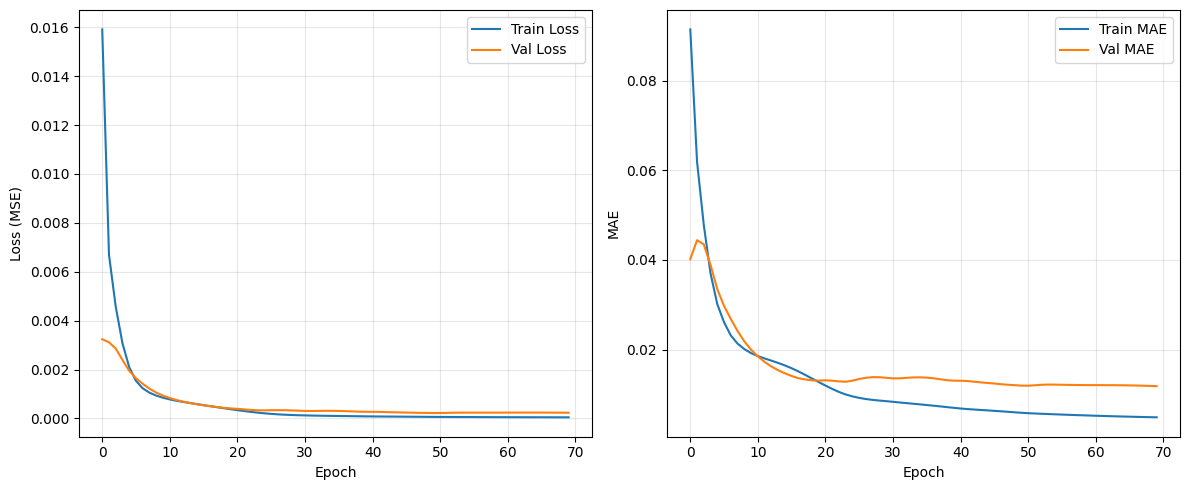

In [19]:
if not _model_loaded_from_cache:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Produktions- und Fehlerdaten bewerten

Beide Strome durchlaufen dieselbe Kette: skalieren mit dem auf der Kampagne
gefitteten Scaler, glaetten, vorhersagen, Modellfehler anhaengen. Wird aus dem
Cache geladen, falls die Artefakte zur Modellkennung schon existieren.


In [20]:
def score(raw, cfg_, case):
    """Vorverarbeiten, vorhersagen, Modellfehler anhaengen -- oder aus dem Cache.

    Ausgewertet wird der vollstaendige Strom einschliesslich der Rampen; die
    Einschraenkung auf Halteintervalle geschieht ueber static_steady_mask.
    """
    if data_store.exists(case, cfg_) and not FORCE_RECOMPUTE:
        df = data_store.load(case, cfg_, rename=True)
        print(f"{case}: aus Cache ({len(df)} Zeilen)")
        return df

    df = preprocess(raw, scaler)
    df["y_pred"] = model.predict(
        df[feature_cols].to_numpy(dtype="float32", copy=False), verbose=0).ravel()
    df["model_error"] = df["y_pred"] - df["cost"]
    df = df.set_index("original_index")
    data_store.save(df, case, cfg_, meta={"feature_cols": list(feature_cols)})
    print(f"{case}: gerechnet und gespeichert ({len(df)} Zeilen)")
    return df


production_preprocessed_data = score(production_data, model_cfg,
                                     "data_scored_production")
error_preprocessed_data = score(error_data, scored_error_cfg, "data_scored_error")

data_scored_production: gerechnet und gespeichert (348481 Zeilen)
data_scored_error: gerechnet und gespeichert (348481 Zeilen)


## Vergleich Modellfehler: nominal vs. Fehlerfall

Stellt den Modellfehler des nominalen Testlaufs und des Fehlerfalls modeweise gegenüber,
normiert beide mit Mittelwert und Streuung des nominalen Testfehlers (identisch zu
*tep_detection*) und legt das rekonstruierte Driftsignal $c(t)$ auf die zweite Ordinate.

In [21]:
# Die Simulationszeit des Fehlerlaufs wird mitgefuehrt, sie argumentiert das
# Driftsignal und beginnt nach jedem Reset wieder bei 0.
combined = []

for mode in production_preprocessed_data["mode"].unique():
    production_temp = (production_preprocessed_data.loc[production_preprocessed_data["mode"] == mode,
                                            ["model_error"]]
                 .reset_index(drop=True))
    fault_temp = (error_preprocessed_data.loc[error_preprocessed_data["mode"] == mode,
                                              ["model_error", "time", "reset",
                                               "driftf", "drift_segment"]]
                  .reset_index(drop=True))
    combined.append(pd.concat([production_temp, fault_temp], axis=1))

combined_data = pd.concat(combined, axis=0, ignore_index=True)
combined_data.columns = ["model_error_normal", "model_error_fault",
                         "time_fault", "reset_fault", "driftf", "drift_segment"]


### Fehler normieren

Der Modellfehler wird mit Mittelwert und Streuung des nominalen Testfehlers normiert,
damit die Ordinate dieselbe Bedeutung hat wie im synthetischen Fall und in *tep_detection*.

In [22]:
_err_free = production_preprocessed_data["model_error"].to_numpy(dtype=float)
NORM_MEAN = float(np.nanmean(_err_free))
NORM_STD = float(np.nanstd(_err_free)) or 1.0

for _c in ("normal", "fault"):
    combined_data[f"error_norm_{_c}"] = (
        (combined_data[f"model_error_{_c}"] - NORM_MEAN) / NORM_STD)

# Darstellungszeit als Zeitstempel, analog syn_generation.
t_h = combined_data.index.to_numpy(dtype=float) / SAMPLES_PER_H
plot_index = pd.to_datetime(t_h * 3600.0, unit="s", origin=pd.Timestamp(PLOT_EPOCH))

_z = combined_data[["error_norm_normal", "error_norm_fault"]].to_numpy(dtype=float)
print(f"{len(combined_data)} Zeitschritte ({t_h[-1]:.0f} h, bis {plot_index[-1]:%d.%m.%Y}) | "
      f"Normierung: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")
print(f"Norm. Fehler: max|z|={np.nanmax(np.abs(_z)):.1f}, "
      f"99.9%-Quantil={np.nanquantile(np.abs(_z), 0.999):.1f} "
      f"-> PLOT_YLIM ggf. anpassen")


348481 Zeitschritte (17424 h, bis 28.12.1971) | Normierung: mean=0.005654, std=0.02027
Norm. Fehler: max|z|=16.0, 99.9%-Quantil=12.0 -> PLOT_YLIM ggf. anpassen


### Driftsignal

Das Driftsignal wird nicht mehr aus `DRIFT_PERIOD` rekonstruiert, sondern aus den Daten gelesen: `driftf` steht als Spalte in `data_error` und ist als Verhältnis der aufgezeichneten Strippertemperatur punktweise exakt. Damit hängt keine Auswertung mehr an einer C-Übersetzung, die nachweislich vom Simulator abweicht.


In [23]:
# driftf = Stripper Temp(Fehler) / Stripper Temp(nominal), aus tep_generation.
cd_signal = combined_data["driftf"].to_numpy(dtype=float) - 1.0

_seg = combined_data.groupby("drift_segment")["time_fault"].agg(["min", "max", "count"])
print(f"Driftsignal (gemessen): min={np.nanmin(cd_signal):.3f}, "
      f"max={np.nanmax(cd_signal):.3f} | "
      f"Kalibrierfaktor in [{1 + np.nanmin(cd_signal):.4f}, {1 + np.nanmax(cd_signal):.4f}]")
print(f"{len(_seg)} Driftsegmente:")
print(_seg.to_string(float_format=lambda v: f"{v:.1f}"))

Driftsignal (gemessen): min=-0.138, max=0.147 | Kalibrierfaktor in [0.8625, 1.1470]
12 Driftsegmente:
                  min     max  count
drift_segment                       
0                 0.0     0.0      1
1                 0.1  1693.7  33873
2              1693.7  3652.5  39177
3              3652.6  5390.1  34751
4              5390.1  7018.2  32563
5              7018.2  8623.0  32095
6              8623.0 10581.2  39165
7             10581.2 12216.0  32696
8             12216.1 14002.6  35731
9             14002.6 15613.9  32227
10            15614.0 17413.5  35993
11            17413.6 17424.0    209


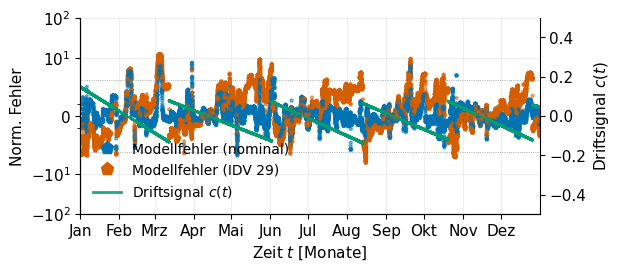

In [24]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

rng_plot = np.random.default_rng(SEED)

PLOT_MONTHS = 12   # None -> alles

_m = slice(None)
if PLOT_MONTHS is not None:
    _m = (plot_index < pd.Timestamp(PLOT_EPOCH) + pd.DateOffset(months=PLOT_MONTHS)).nonzero()[0]

fig, ax, ax2 = ts.error_timeseries(
    plot_index[_m],
    [(combined_data["error_norm_normal"].to_numpy(dtype=float)[_m],
      "drift_free", "Modellfehler (nominal)"),
     (combined_data["error_norm_fault"].to_numpy(dtype=float)[_m],
      "drift_afflicted", f"Modellfehler (IDV {ERROR_VARIANT_ID})")],
    cd=cd_signal[_m],
    ylabel="Norm. Fehler",
        xlabel="Zeit $t$ [Monate]",
        cd_label="Driftsignal $c(t)$",
        ylim=PLOT_YLIM, cd_amp=0.5, cd_tick_step=0.2,
        frac=PLOT_FRAC, rng=rng_plot, height_scale=0.45,
        legend=dict(loc="lower left", markerscale=1),
)
fig.tight_layout()
plot_store.save_figure(fig, "model_error", scored_error_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()

## Numerische Auswertung der Modelldegradation

In [25]:
# Kennzahlen getrennt nach gesehenen und ungesehenen Betriebspunkten.
_seen = production_preprocessed_data["mode"].isin(campaign_modes).to_numpy()
_r0 = production_preprocessed_data["model_error"].to_numpy(dtype=float)
_r1 = error_preprocessed_data["model_error"].to_numpy(dtype=float)
_seen_e = error_preprocessed_data["mode"].isin(campaign_modes).to_numpy()

def _stats(a, b):
    return dict(rmse_free=np.sqrt(np.nanmean(a ** 2)),
                rmse_fault=np.sqrt(np.nanmean(b ** 2)),
                std_free=np.nanstd(a), bias_fault=np.nanmean(b),
                std_fault=np.nanstd(b),
                K=np.sqrt(np.nanmean(b ** 2)) / (np.sqrt(np.nanmean(a ** 2)) or np.nan))

# Die Zeilennamen gehen unveraendert in die LaTeX-Makronamen, daher nur Buchstaben.
stats = pd.DataFrame({
    "Alle": _stats(_r0, _r1),
    "Ungesehen": _stats(_r0[~_seen], _r1[~_seen_e]),
    "Gesehen": _stats(_r0[_seen], _r1[_seen_e]),
}).T
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(stats.to_string())
print(f"\n{int((~_seen).sum())} von {len(_seen)} Zeilen auf ungesehenen Punkten "
      f"({production_preprocessed_data.loc[~_seen, 'mode'].nunique()} Betriebspunkte)")

r0, r1 = _r0[~_seen], _r1[~_seen_e]

           rmse_free  rmse_fault  std_free  bias_fault  std_fault     K
Alle         0.02105     0.03977   0.02027     0.01132    0.03813  1.89
Ungesehen      0.023     0.04159   0.02204     0.01357    0.03932 1.809
Gesehen      0.01201     0.03266   0.01175    0.003506    0.03248 2.721

270720 von 348481 Zeilen auf ungesehenen Punkten (94 Betriebspunkte)


## Modellfehler über dem Abstand zur Kampagne

Der eigentliche Ertrag der modusweisen Datengrundlage. Für jeden Produktionspunkt der Abstand zum nächsten Kampagnenpunkt im skalierten Sollwertraum gegen den Modellfehler. Daraus wird begründet, bis zu welcher Abweichung vom Versuchsplan der Drift sichtbar bleibt — statt diese Grenze zu setzen.


In [26]:
# Abstand wahlweise im Sollwert- oder im Merkmalsraum.
DIST_SPACE = "feature"        # "feature" | "setpoint"

_pm = static_steady_mask(production_preprocessed_data, ramp_duration, soak_time)
_em = static_steady_mask(error_preprocessed_data, ramp_duration, soak_time)
_ph, _eh = production_preprocessed_data[_pm], error_preprocessed_data[_em]

_rms = lambda s: float(np.sqrt(np.nanmean(np.asarray(s, float) ** 2)))
point = pd.DataFrame({
    "err_free": _ph.groupby("mode")["model_error"].apply(_rms),
    "err_fault": _eh.groupby("mode")["model_error"].apply(_rms),
    "cost": _ph.groupby("mode")["cost"].mean(),
})
point["d_e"] = (_eh.groupby("mode")["model_error"].mean()
                - _ph.groupby("mode")["model_error"].mean()).abs()
point["gesehen"] = point.index.isin(campaign_modes)


def _min_dist(cols):
    """Abstand je Produktionspunkt zum naechsten Kampagnenpunkt, skaliert auf
    die Spannweite des Kampagnenpools."""
    lo, hi = campaign_means_all[cols].min(), campaign_means_all[cols].max()
    span = (hi - lo).replace(0.0, 1.0)
    up = (_ph.groupby("mode")[cols].mean() - lo) / span
    uc = (campaign_means_all.loc[campaign_modes, cols] - lo) / span
    return cdist(up.to_numpy(), uc.to_numpy()).min(axis=1)


point["dist_sp"] = _min_dist(setpoint_cols)
point["dist_feat"] = _min_dist(list(feature_cols))
_dcol = "dist_feat" if DIST_SPACE == "feature" else "dist_sp"

print(f"{len(point)} Produktionspunkte, davon {int(point['gesehen'].sum())} gesehen")
print(f"Abstand Sollwertraum ({len(setpoint_cols)}D): "
      f"{point['dist_sp'].min():.3f} .. {point['dist_sp'].max():.3f}")
print(f"Abstand Merkmalsraum ({len(feature_cols)}D): "
      f"{point['dist_feat'].min():.3f} .. {point['dist_feat'].max():.3f}")
_ung = ~point["gesehen"]
for _c in ("dist_sp", "dist_feat"):
    print(f"  corr(err_free, {_c:9s}) ueber die ungesehenen Punkte = "
          f"{np.corrcoef(point.loc[_ung, _c], point.loc[_ung, 'err_free'])[0, 1]:+.3f}")

print("\nZerlegung von RMSE_frei:")
for _lab, _sel in (("gesehen (Abstand 0)", point["gesehen"]), ("ungesehen", _ung)):
    if _sel.any():
        print(f"  {_lab:22s} n={int(_sel.sum()):3d}  RMSE {_rms(point.loc[_sel, 'err_free']):7.4f}"
              f"  Abstand Median {point.loc[_sel, _dcol].median():.3f}")

_edges = np.quantile(point.loc[_ung, _dcol], np.linspace(0, 1, 6))
_edges[0], _edges[-1] = _edges[0] - 1e-9, _edges[-1] + 1e-9
point["klasse"] = pd.cut(point[_dcol], np.unique(_edges))
_curve = point.groupby("klasse", observed=True).agg(
    n=("err_free", "size"), abstand=(_dcol, "median"),
    rmse_frei=("err_free", _rms), d_e=("d_e", "mean"))
_curve["verhaeltnis"] = _curve["d_e"] / _curve["rmse_frei"]
print(f"\nAbstandsklassen im {DIST_SPACE}-Raum:")
print(_curve.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nverhaeltnis > 1 heisst: die driftbedingte Verschiebung uebersteigt den")
print("nominalen Fehler -- ab dort ist der Drift im Modellfehler sichtbar.")

121 Produktionspunkte, davon 27 gesehen
Abstand Sollwertraum (12D): 0.000 .. 1.000
Abstand Merkmalsraum (5D): 0.000 .. 0.500
  corr(err_free, dist_sp  ) ueber die ungesehenen Punkte = -0.117
  corr(err_free, dist_feat) ueber die ungesehenen Punkte = +0.466

Zerlegung von RMSE_frei:
  gesehen (Abstand 0)    n= 27  RMSE  0.0076  Abstand Median 0.001
  ungesehen              n= 94  RMSE  0.0273  Abstand Median 0.159

Abstandsklassen im feature-Raum:
                  n  abstand  rmse_frei    d_e  verhaeltnis
klasse                                                     
(0.0174, 0.079]  19   0.0569     0.0124 0.0183       1.4714
(0.079, 0.133]   20   0.1042     0.0125 0.0189       1.5193
(0.133, 0.2]     18   0.1594     0.0192 0.0182       0.9508
(0.2, 0.307]     19   0.2252     0.0312 0.0276       0.8828
(0.307, 0.5]     19   0.3903     0.0454 0.0335       0.7375

verhaeltnis > 1 heisst: die driftbedingte Verschiebung uebersteigt den
nominalen Fehler -- ab dort ist der Drift im Modellfehler

In [27]:
## Driftwirkung je Segment
_seg_tbl = (combined_data.groupby("drift_segment")
            .agg(n=("model_error_fault", "size"),
                 t_min=("time_fault", "min"), t_max=("time_fault", "max"),
                 driftf_min=("driftf", "min"), driftf_max=("driftf", "max"),
                 rmse_frei=("model_error_normal", _rms),
                 rmse_fehler=("model_error_fault", _rms)))
_seg_tbl["K"] = _seg_tbl["rmse_fehler"] / _seg_tbl["rmse_frei"]
print(_seg_tbl.to_string(float_format=lambda v: f"{v:.3f}"))

# Korrelation der Fehlerverschiebung mit dem Driftsignal, je Segment
print("\nKorrelation (Fehlerdifferenz, driftf) je Segment:")
for _s, _g in combined_data.groupby("drift_segment"):
    _dy = (_g["model_error_fault"] - _g["model_error_normal"]).to_numpy(dtype=float)
    _ok = np.isfinite(_dy) & np.isfinite(_g["driftf"].to_numpy(dtype=float))
    if _ok.sum() > 10:
        print(f"  Segment {int(_s)}: n={int(_ok.sum()):6d}  "
              f"corr = {np.corrcoef(_dy[_ok], _g['driftf'].to_numpy(float)[_ok])[0, 1]:+.3f}")

                   n     t_min     t_max  driftf_min  driftf_max  rmse_frei  rmse_fehler     K
drift_segment                                                                                 
0                  1     0.000     0.000       1.000       1.000      0.001        0.001 1.000
1              33873     0.050  1693.650       0.868       1.147      0.035        0.063 1.787
2              39177  1693.700  3652.500       0.872       1.077      0.019        0.043 2.247
3              34751  3652.550  5390.050       0.862       1.072      0.018        0.035 1.997
4              32563  5390.100  7018.200       0.879       1.063      0.020        0.039 1.922
5              32095  7018.250  8622.950       0.877       1.074      0.014        0.032 2.269
6              39165  8623.000 10581.200       0.933       1.055      0.012        0.021 1.743
7              32696 10581.250 12216.000       0.917       1.092      0.033        0.052 1.565
8              35731 12216.050 14002.550       0.9

## Ergebnisse speichern

In [28]:
from src.utils import results_export as rx

_keys = [(k, k, "num") for k in
         ["rmse_free", "rmse_fault", "std_free", "bias_fault", "std_fault"]]

(rx.ResultDoc()
   .integer("n_test", len(production_preprocessed_data))
   .integer("n_error", len(error_preprocessed_data))
   .stats(stats, _keys, into="models")
   .save(res_store, "model_error", scored_error_cfg, final=IS_FINAL))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\tep_model_error.json


'C:\\git\\process_optimization_concept_drift\\results\\tep_model_error.json'

In [29]:
from src.utils import latex_export as lx

mx = lx.MacroExport("automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant, Sektion 'model')")
mx.param("tepParamWindow", model_params["window_size"])
mx.param("tepParamEpochs", model_params["epochs"])
mx.param("tepParamBatch", model_params["batch"])
mx.param("tepParamPatience", model_params["patience"])
mx.param("tepParamValSplitPct", round(model_params["val_split"] * 100))
mx.param("tepParamNeurons", model_params["arch"][0])
mx.param("tepParamNLayers", len(model_params["arch"]) - 1, spell_out=True)
mx.param("tepParamNFeatures", len(model_params["features"]), spell_out=True)
mx.param("tepParamNCampaign", model_params["n_campaign"])

mx.comment("Ergebnisse (Modellfehler-Statistiken)")
mx.stats(stats, [("rmse_free", "RmseFree", 3), ("rmse_fault", "RmseFault", 3),
                 ("std_free", "SigmaFree", 3), ("bias_fault", "Bias", 3),
                 ("std_fault", "Sigma", 3), ("K", "K", 3)], prefix="tepstat")

mx.save(res_store, "model_error", scored_error_cfg, final=IS_FINAL)


LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\tep_model_error.tex

% automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren

% Parameter (Hash-relevant, Sektion 'model')
\newcommand{\tepParamWindow}{10}
\newcommand{\tepParamEpochs}{200}
\newcommand{\tepParamBatch}{200}
\newcommand{\tepParamPatience}{20}
\newcommand{\tepParamValSplitPct}{15}
\newcommand{\tepParamNeurons}{12}
\newcommand{\tepParamNLayers}{zwei}
\newcommand{\tepParamNFeatures}{fünf}
\newcommand{\tepParamNCampaign}{30}

% Ergebnisse (Modellfehler-Statistiken)
\newcommand{\tepstatAlleRmseFree}{0{,}021}
\newcommand{\tepstatAlleRmseFault}{0{,}040}
\newcommand{\tepstatAlleSigmaFree}{0{,}020}
\newcommand{\tepstatAlleBias}{0{,}011}
\newcommand{\tepstatAlleSigma}{0{,}038}
\newcommand{\tepstatAlleK}{1{,}890}
\newcommand{\tepstatUngesehenRmseFree}{0{,}023}
\newcommand{\tepstatUngesehenRmseFault}{0{,}042}
\newcommand{\tepstatUngesehenSigmaFree}{0{,}022}
\newcommand{\tepstatUngesehenBias}{0{,}014}
\newc

'C:\\git\\process_optimization_concept_drift\\results\\tep_model_error.tex'

## Lauf abgeschlossen

Zeigt die Kennungen dieses Laufs in einem Fenster mit Kopier-Button (Konsolenausgabe, falls keine GUI verfuegbar ist).

In [30]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Modellbildung beendet.\n"
    f"Model Run-ID: {model_cfg.id}\n"
    f"Fehlerfall (IDV {ERROR_VARIANT_ID}): {scored_error_cfg.id}",
    copy_value=model_cfg.id,
)


--- Lauf abgeschlossen ---
Modellbildung beendet.
Model Run-ID: 629ff00f
Fehlerfall (IDV 29): 5d29a9f2



## Screening: Kampagnengröße

Eigene Zelle, damit `N_CAMPAIGN` im Hauptlauf ein Skalar bleibt. Alles hier ist lokal (`_sw`-Präfix), der Zustand des Notebooks wird nicht verändert — Modell, Merkmalssatz und Kennzahlen oben bleiben die des eingestellten `N_CAMPAIGN`.

Für jede Größe werden Merkmalsauswahl und Netz neu gerechnet und auf den **ungesehenen** Produktionspunkten bewertet. Bei der vollen Poolgröße gibt es keine ungesehenen mehr; diese Zeile ist das Szenario „wiederkehrende Betriebspunkte" aus Handoff 10.1.


In [ ]:
SWEEP_SIZES = (12, 18, 30, 60, 90)
SWEEP_VAL_MODES = ("segment", "ramp")   # Merkmalssatz ist immer FEATURE_SET
RUN_SWEEP = True     # nach dem Screening auf False setzen

if RUN_SWEEP:
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers
    from keras.callbacks import EarlyStopping

    _sw_pm = static_steady_mask(production_preprocessed_data, ramp_duration, soak_time)
    _sw_em = static_steady_mask(error_preprocessed_data, ramp_duration, soak_time)
    _sw_ph = production_preprocessed_data[_sw_pm]
    _sw_eh = error_preprocessed_data[_sw_em]
    _sw_rms = lambda a: float(np.sqrt(np.nanmean(np.asarray(a, float) ** 2)))

    def _sw_run(n, val_mode):
        _modes = pick_campaign(n)
        _, _ranges = campaign_subset(_modes)
        _feat = list(FEATURE_SET)
        _tr = pd.concat([campaign_smoothed_data.loc[
            (campaign_smoothed_data["original_index"] >= s)
            & (campaign_smoothed_data["original_index"] <= e), :] for s, e in _ranges])
        _x, _y = _tr[_feat].to_numpy("float32"), _tr["cost"].to_numpy("float32")

        if val_mode == "ramp":
            _c = campaign_smoothed_data[campaign_smoothed_data["mode"].isin(_modes)]
            _v = _c[static_ramp_mask(_c, ramp_duration)]
            _xtr, _ytr = _x, _y
            _xv = _v[_feat].to_numpy("float32"); _yv = _v["cost"].to_numpy("float32")
            _nvp = int(_v["mode"].nunique())
        else:
            _segid = np.zeros(len(_tr), dtype=int)
            _oi = _tr["original_index"].to_numpy()
            for k, (s, e) in enumerate(_ranges):
                _segid[(_oi >= s) & (_oi <= e)] = k
            _nval = max(1, round(VAL_SPLIT * len(_ranges)))
            _vseg = np.random.default_rng(SEED).choice(np.unique(_segid), _nval,
                                                       replace=False)
            _isv = np.isin(_segid, _vseg)
            _xtr, _ytr = _x[~_isv], _y[~_isv]
            _xv, _yv = _x[_isv], _y[_isv]
            _nvp = int(len(_vseg))

        tf.keras.utils.set_random_seed(SEED)
        _m = keras.Sequential([layers.Input(shape=(len(_feat),))]
                              + [layers.Dense(u, activation=ACT) for u in ARCH[:-1]]
                              + [layers.Dense(ARCH[-1])])
        _m.compile(optimizer="adam", loss="mse")
        _hist = _m.fit(_xtr, _ytr, validation_data=(_xv, _yv),
                       epochs=EPOCHS, batch_size=BATCH, verbose=0,
                       callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                                restore_best_weights=True)])

        _unseen_p = ~_sw_ph["mode"].isin(_modes).to_numpy()
        _unseen_e = ~_sw_eh["mode"].isin(_modes).to_numpy()
        if _unseen_p.sum() < 100:      # keine ungesehenen Punkte mehr
            _unseen_p[:] = True; _unseen_e[:] = True
        _r0 = (_m.predict(_sw_ph[_feat].to_numpy("float32"), verbose=0).ravel()
               - _sw_ph["cost"].to_numpy())[_unseen_p]
        _r1 = (_m.predict(_sw_eh[_feat].to_numpy("float32"), verbose=0).ravel()
               - _sw_eh["cost"].to_numpy())[_unseen_e]
        _f = _sw_rms(_r0)
        return dict(n_kampagne=n, variante=val_mode,
                    n_ungesehen=int(_sw_ph.loc[_unseen_p, "mode"].nunique()),
                    n_val_pt=_nvp, n_train=len(_xtr),
                    epochen=len(_hist.history["loss"]),
                    rmse_frei=_f, rmse_fehler=_sw_rms(_r1),
                    K=_sw_rms(_r1) / (_f or np.nan))

    sweep = pd.DataFrame([_sw_run(n, v) for n in SWEEP_SIZES
                          if n <= len(campaign_means_all) for v in SWEEP_VAL_MODES])
    _piv = sweep.pivot(index="n_kampagne", columns="variante",
                       values=["rmse_frei", "K", "epochen", "n_val_pt"])
    _piv[("n", "ungesehen")] = sweep.groupby("n_kampagne")["n_ungesehen"].first()
    print(_piv.to_string(float_format=lambda v: f"{v:.4f}"))
    print(f"\nMerkmalssatz: {', '.join(FEATURE_SET)}")
    print(f"Eingestellt: N_CAMPAIGN = {N_CAMPAIGN}, VAL_MODE = {VAL_MODE!r}, "
          f"amp = {error_variant['amp']}.")
    print("\nEin Abbruch nahe PATIENCE + 1 = "
          f"{PATIENCE + 1} bedeutet, dass die beste Epoche die erste war -- das")
    print("Early Stopping hat dann nicht die Anpassung gemessen, sondern Rauschen.")